# Part II — From Sequences to Transformers

## Recap: Where We Left Off

In Part I we built a complete pipeline:

- **BPE tokenization** — raw text → subword token IDs (open vocabulary)
- **Embeddings** — token IDs → dense vectors that carry semantic meaning
- **MLP** — embeddings → softmax → probability over next token

This pipeline works. But it treats its input as an **unordered bag of tokens**. "The cat sat" and "sat cat the" produce the same prediction. The model has no concept of sequence, order, or structure.

That is the problem we solve in this notebook.

---

## The Road Ahead

| Chapter | Concept | Problem Solved |
|---------|---------|----------------|
| 7 | RNN | Process tokens in order (but forget early context) |
| 8 | LSTM | Better long-term memory (but sequential bottleneck) |
| 9 | Attention | Look at all positions directly (but still uses RNN) |
| 10 | Transformer | Everything at once: parallel, deep, contextual |
| 11 | Generation | Turn the trained model into a text generator |


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import sys
sys.path.append('..')

from llmkit import data, viz
from llmkit.solutions import (
    ch06_bpe,
    ch07_rnn,
    ch08_lstm,
    ch09_attention,
    ch10_transformer,
    ch11_generation,
)

torch.manual_seed(42)
np.random.seed(42)

# Download and prepare WikiText-2
print("Loading corpus...")
corpus = data.get_full_corpus()
print(f"Corpus length: {len(corpus.split())} words")

# Train BPE tokenizer (re-use from Chapter 6)
print("Training BPE tokenizer...")
tokenizer = ch06_bpe.BytePairEncoding(vocab_size=2000)
tokenizer.train(corpus)
print(f"Vocabulary size: {len(tokenizer.vocab)} tokens")

# Encode the corpus to token IDs
token_ids = data.get_token_ids(corpus, tokenizer)
VOCAB_SIZE = len(tokenizer.vocab)
print(f"Total tokens: {len(token_ids)}, Vocab size: {VOCAB_SIZE}")
print("\nSetup complete!")

Loading corpus...
Corpus length: 2051910 words
Training BPE tokenizer...
Vocabulary size: 2000 tokens
Total tokens: 2707219, Vocab size: 2000

Setup complete!


---

## The PyTorch Transition

> We built backpropagation by hand. We understand how gradients flow through a network. From here, the new ideas are in the *architectures* themselves — not the gradient plumbing. We let PyTorch handle what we've already proven we understand, so we can focus on what's new.

| Chapters | Tensors | Forward Pass | Backward Pass |
|----------|---------|-------------|---------------|
| 1–6 | `np.array` | Handwritten | Manual gradients + updates |
| 7–11 | `torch.Tensor` | **Handwritten** | `loss.backward()` + `optimizer.step()` |

The forward pass stays ours. The backward pass becomes automatic.


---

# Chapter 7: Recurrent Neural Network

**Track:** Prediction  
**Question:** How do we make the model aware of sequence and order?

---

## 7.1  Sliding Window Data Preparation

- **Unsupervised → supervised** — slide a window of length $T$; input = window, target = window shifted +1
- **No labels needed** — the next token *is* the label
- **Same token, two roles** — appears as input at position $i$, target at position $i-1$

$$\text{input}_i = [t_i,\ldots,t_{i+T-1}] \qquad \text{target}_i = [t_{i+1},\ldots,t_{i+T}]$$

| Symbol | Meaning |
|--------|---------|
| $t_i$ | Token ID at position $i$ |
| $T$ | Window / sequence length |

## 7.1 Exercise

Implement the sliding window sequence builder.

In [2]:
def your_prepare_sequences(token_ids, seq_len=32):
    """Create (input, target) pairs by sliding a window over token_ids.

    Each input[i] = token_ids[i : i+seq_len]
    Each target[i] = token_ids[i+1 : i+seq_len+1]  (shifted right by 1)
    """
    if not isinstance(token_ids, torch.Tensor):
        token_ids = torch.tensor(token_ids, dtype=torch.long)

    inputs, targets = [], []
    for i in range(len(token_ids) - seq_len):
        # TODO: implement this
        inputs.append(...)
        # TODO: implement this
        targets.append(...)

    return torch.stack(inputs), torch.stack(targets)

# Quick check
test_ids = torch.arange(20)
try:
    inp, tgt = your_prepare_sequences(test_ids, seq_len=5)
    print(f"inputs shape:  {inp.shape}   (expected: (15, 5))")
    print(f"targets shape: {tgt.shape}   (expected: (15, 5))")
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODOs above, then re-run")

[NOT IMPLEMENTED] — fill in the TODOs above, then re-run


## 7.1 Verify & Compare

In [3]:
ref_inp, ref_tgt = ch07_rnn.prepare_sequences(test_ids, seq_len=5)

try:
    your_inp, your_tgt = your_prepare_sequences(test_ids, seq_len=5)
    your_inp_np = your_inp.numpy()
    your_tgt_np = your_tgt.numpy()
except Exception:
    your_inp_np = ...
    your_tgt_np = ...

viz.compare(your_inp_np, ref_inp.numpy())
viz.compare(your_tgt_np, ref_tgt.numpy())
your_inp = viz.resolve(your_inp_np, ref_inp.numpy())
your_tgt = viz.resolve(your_tgt_np, ref_tgt.numpy())

# Build dataset for training (use reference from now on)
SEQ_LEN = 32
inputs, targets = ch07_rnn.prepare_sequences(token_ids, seq_len=SEQ_LEN)
print(f"\nDataset: {len(inputs)} sequences of length {SEQ_LEN}")

[NOT IMPLEMENTED] Found ... placeholder
[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation
[SKIPPED] Using reference implementation

Dataset: 2707187 sequences of length 32


## 7.2  The RNN Step

- **One token at a time** — takes $x_t$ (current embedding) and $h_{t-1}$ (memory)
- **Single memory vector** — $h_t$ carries all history; the only thing passed forward
- **tanh squash** — keeps values in $[-1, 1]$, prevents blow-up

$$h_t = \tanh\!\left(x_t W_{xh} + h_{t-1} W_{hh} + b_h\right)$$

| Symbol | Shape |
|--------|-------|
| $x_t$ | $(B,\ d_\text{embed})$ |
| $h_t$ | $(B,\ d_\text{hidden})$ |
| $W_{hh}$ | $(d_h,\ d_h)$ — recurrent weights |

## 7.2 Exercise

Implement a single RNN timestep.

In [4]:
def your_rnn_step(x_t, h_prev, W_xh, W_hh, b_h):
    """Single RNN timestep: h_t = tanh(x_t @ W_xh + h_prev @ W_hh + b_h)

    Args:
        x_t:    (batch, embed_dim)
        h_prev: (batch, hidden_size)
        W_xh:   (embed_dim, hidden_size)
        W_hh:   (hidden_size, hidden_size)
        b_h:    (hidden_size,)

    Returns:
        h_t: (batch, hidden_size)
    """
    # TODO: implement this
    linear = ...
    # TODO: implement this
    h_t = ...
    return h_t

# Quick shape check
batch, embed_dim, hidden_size = 4, 16, 32
x_test    = torch.randn(batch, embed_dim)
h_test    = torch.zeros(batch, hidden_size)
W_xh_test = torch.randn(embed_dim, hidden_size) * 0.01
W_hh_test = torch.randn(hidden_size, hidden_size) * 0.01
b_h_test  = torch.zeros(hidden_size)

try:
    h_out = your_rnn_step(x_test, h_test, W_xh_test, W_hh_test, b_h_test)
    print(f"h_t shape: {h_out.shape}  (expected: ({batch}, {hidden_size}))")
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODOs above, then re-run")

[NOT IMPLEMENTED] — fill in the TODOs above, then re-run


## 7.2 Verify & Compare

In [5]:
ref_h_out = ch07_rnn.rnn_step(x_test, h_test, W_xh_test, W_hh_test, b_h_test)

try:
    your_h_out = your_rnn_step(x_test, h_test, W_xh_test, W_hh_test, b_h_test)
    your_h_out_np = your_h_out.detach().numpy()
except Exception:
    your_h_out_np = ...

viz.compare(your_h_out_np, ref_h_out.detach().numpy())
your_h_out = viz.resolve(your_h_out_np, ref_h_out.detach().numpy())

[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation


## 7.2 Visualize

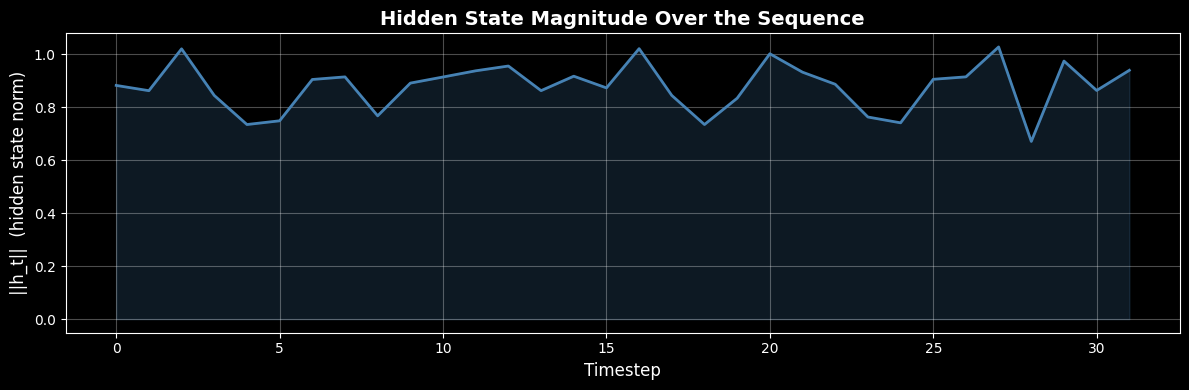

In [6]:
# Show hidden state norms over a short sequence
model_rnn = ch07_rnn.RNNLanguageModel(VOCAB_SIZE, embed_dim=64, hidden_size=128)

with torch.no_grad():
    sample_input = inputs[:1]                       # 1 sequence
    emb = model_rnn.embedding(sample_input)         # (1, seq_len, embed_dim)
    h = torch.zeros(1, 128)
    h_seq = []
    for t in range(emb.shape[1]):
        h = ch07_rnn.rnn_step(emb[:, t, :], h, model_rnn.W_xh, model_rnn.W_hh, model_rnn.b_h)
        h_seq.append(h[0].numpy())
    h_seq = np.array(h_seq)   # (seq_len, hidden_size)

viz.plot_hidden_states(h_seq)


## 7.3  Training an RNN

- **Unroll through time** — autograd tracks gradients across every timestep automatically
- **Gradient clipping** — if $\|g\| > \text{clip}$, rescale: $g \leftarrow g \cdot \tfrac{\text{clip}}{\|g\|}$
- **Vanishing gradients** — $0.9^{50} \approx 0.005$; early tokens stop influencing the loss
- **Exploding gradients** — $1.1^{50} \approx 117$; clipping fixes this, vanishing needs LSTM

$$\text{if } \|g\| > c: \quad g \leftarrow g \cdot \frac{c}{\|g\|}$$

| Symbol | Meaning |
|--------|---------|
| $g$ | Flattened gradient vector |
| $c$ | Clip norm threshold (e.g. 1.0) |

## 7.3 Exercise

Complete the training loop for the RNN language model.

In [7]:
def your_train_rnn_step(model, xb, yb, optimizer, criterion):
    """One training step for the RNN language model.

    Args:
        model:     RNNLanguageModel
        xb:        (batch, seq_len) input token ids
        yb:        (batch, seq_len) target token ids
        optimizer: PyTorch optimizer
        criterion: loss function (CrossEntropyLoss)

    Returns:
        loss: scalar float
    """
    # TODO: implement this
    logits, _ = ...

    # Reshape for cross-entropy: (batch*seq, vocab) vs (batch*seq,)
    bs, sl, v = logits.shape
    # TODO: implement this
    loss = criterion(..., ...)

    # TODO: implement this
    ...
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    # TODO: implement this
    ...

    return loss.item()

print("Training step defined (fill in the blanks above to try it)")


Training step defined (fill in the blanks above to try it)


## 7.3 Verify & Compare

In [8]:
# Train RNN with reference implementation
print("Training RNN language model...")
rnn_model = ch07_rnn.RNNLanguageModel(VOCAB_SIZE, embed_dim=64, hidden_size=128)
rnn_model, rnn_losses = ch07_rnn.train_rnn(
    rnn_model, inputs, targets,
    n_epochs=5, batch_size=64, lr=1e-3, verbose=True
)
print(f"\nFinal loss: {rnn_losses[-1]:.4f}")

Training RNN language model...
Epoch 1/5  loss: 3.3158
Epoch 2/5  loss: 3.1816
Epoch 3/5  loss: 3.1541
Epoch 4/5  loss: 3.1401
Epoch 5/5  loss: 3.1315

Final loss: 3.1315


## 7.3 Visualize

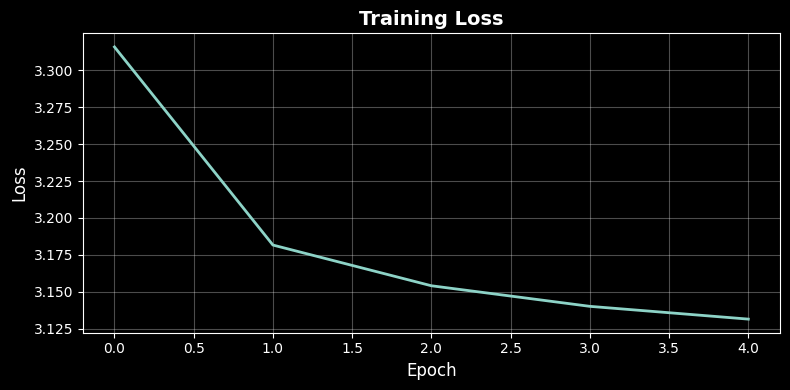

In [9]:
viz.plot_loss_curve(rnn_losses, xlabel="Epoch")

### Sample Output — RNN

The model has only seen loss numbers so far. Let's see what text it actually produces.
Even after a short training run, you should see it picking up common tokens and basic patterns.

In [ ]:
samples = {}
for prompt in ["the", "in the", "he was"]:
    samples[f'"{prompt}"'] = ch11_generation.generate(
        rnn_model, tokenizer, prompt, max_new_tokens=40, strategy='greedy'
    )
viz.plot_generation_samples(samples)

In [ ]:
import os, pickle
os.makedirs('../models', exist_ok=True)
torch.save(rnn_model.state_dict(), '../models/rnn_model.pt')
print("Saved: models/rnn_model.pt")

**Key Takeaway:**
> We can process sequences now, but the model's memory fades with distance.

---

# Chapter 8: Long Short-Term Memory (LSTM)

**Track:** Prediction  
**Question:** Can we give the network a better mechanism for long-term memory?

---

## 8.1  Cell State and Gates

- **Cell state $c_t$** — dedicated memory lane; flows across time with minimal squashing
- **Forget gate $f_t$** — sigmoid in $[0,1]$; 0 = erase, 1 = keep old memory
- **Input gate $i_t$** — controls how much new information enters
- **Output gate $o_t$** — controls what part of $c_t$ is exposed as $h_t$

$$f_t = \sigma(x_t W_{xf} + h_{t-1} W_{hf} + b_f)$$

| Gate | Activation | Role |
|------|-----------|------|
| Forget $f$ | sigmoid | Erase old cell state |
| Input $i$ | sigmoid | Write new information |
| Candidate $g$ | tanh | What *could* be written |
| Output $o$ | sigmoid | What to expose as $h_t$ |

## 8.1 Exercise

Implement the forget and input gate computations.

In [11]:
def your_forget_gate(x_t, h_prev, W_xf, W_hf, b_f):
    """Forget gate: f_t = sigmoid(x_t @ W_xf + h_prev @ W_hf + b_f)"""
    # TODO: implement this
    return ...

def your_input_gate(x_t, h_prev, W_xi, W_hi, b_i):
    """Input gate: i_t = sigmoid(x_t @ W_xi + h_prev @ W_hi + b_i)"""
    # TODO: implement this
    return ...

# Test
x_t    = torch.randn(4, 16)
h_prev = torch.randn(4, 32)
W_xf   = torch.randn(16, 32) * 0.01
W_hf   = torch.randn(32, 32) * 0.01
b_f    = torch.zeros(32)
W_xi, W_hi, b_i = W_xf.clone(), W_hf.clone(), b_f.clone()

try:
    f_t = your_forget_gate(x_t, h_prev, W_xf, W_hf, b_f)
    i_t = your_input_gate(x_t, h_prev, W_xi, W_hi, b_i)
    print(f"Forget gate shape: {f_t.shape}")
    print(f"Input  gate shape: {i_t.shape}")
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODOs above, then re-run")

[NOT IMPLEMENTED] — fill in the TODOs above, then re-run


## 8.1 Verify & Compare

In [12]:
ref_f_t = torch.sigmoid(x_t @ W_xf + h_prev @ W_hf + b_f)

try:
    your_f_t = your_forget_gate(x_t, h_prev, W_xf, W_hf, b_f)
    your_f_t_np = your_f_t.detach().numpy()
except Exception:
    your_f_t_np = ...

viz.compare(your_f_t_np, ref_f_t.detach().numpy())
your_f_t = viz.resolve(your_f_t_np, ref_f_t.detach().numpy())

[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation


## 8.2  The LSTM Step

- **Cell update** — linear combination: $c_t = f_t \odot c_{t-1} + i_t \odot g_t$
- **No activation on $c_t$ path** — gradients flow back without shrinking → long-range learning
- **Hidden state** — $h_t = o_t \odot \tanh(c_t)$; filtered view of memory
- **$f=0.9$** → 90 % of previous memory survives; **$f=0.02$** → cell resets

$$c_t = f_t \odot c_{t-1} + i_t \odot g_t \qquad h_t = o_t \odot \tanh(c_t)$$

| Symbol | Meaning |
|--------|---------|
| $\odot$ | Element-wise multiply |
| $f_t \odot c_{t-1}$ | What to keep from old memory |
| $i_t \odot g_t$ | What to write as new memory |

## 8.2 Exercise

Implement the full LSTM step.

In [13]:
def your_lstm_step(x_t, h_prev, c_prev, W_x, W_h, b):
    """Single LSTM timestep.

    W_x, W_h, b are stacked for all 4 gates along dim=-1:
    [forget | input | gate | output] — each of size hidden_size.

    Args:
        x_t:    (batch, embed_dim)
        h_prev: (batch, hidden_size)
        c_prev: (batch, hidden_size)
        W_x:    (embed_dim, 4*hidden_size)
        W_h:    (hidden_size, 4*hidden_size)
        b:      (4*hidden_size,)

    Returns:
        h_t: (batch, hidden_size)
        c_t: (batch, hidden_size)
    """
    # Combined linear map for all gates
    gates = x_t @ W_x + h_prev @ W_h + b   # (batch, 4*hidden_size)
    hidden_size = h_prev.shape[1]

    # Split into 4 gates and apply activations
    f = torch.sigmoid(gates[:, 0 * hidden_size : 1 * hidden_size])   # forget
    # TODO: implement this
    i = ...   # input gate (sigmoid)
    # TODO: implement this
    g = ...   # cell candidate (tanh)
    # TODO: implement this
    o = ...   # output gate (sigmoid)

    # TODO: implement this
    c_t = ...
    # TODO: implement this
    h_t = ...
    return h_t, c_t

# Shape check
batch, embed, hid = 4, 16, 32
x_t    = torch.randn(batch, embed)
h_prev = torch.zeros(batch, hid)
c_prev = torch.zeros(batch, hid)
W_x    = torch.randn(embed, 4 * hid) * 0.01
W_h    = torch.randn(hid,  4 * hid) * 0.01
b      = torch.zeros(4 * hid)

try:
    h_t, c_t = your_lstm_step(x_t, h_prev, c_prev, W_x, W_h, b)
    print(f"h_t shape: {h_t.shape},  c_t shape: {c_t.shape}")
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODOs above, then re-run")

[NOT IMPLEMENTED] — fill in the TODOs above, then re-run


## 8.2 Verify & Compare

In [14]:
ref_h_t, ref_c_t = ch08_lstm.lstm_step(x_t, h_prev, c_prev, W_x, W_h, b)

try:
    your_h_t, your_c_t = your_lstm_step(x_t, h_prev, c_prev, W_x, W_h, b)
    your_h_t_np = your_h_t.detach().numpy()
    your_c_t_np = your_c_t.detach().numpy()
except Exception:
    your_h_t_np = ...
    your_c_t_np = ...

viz.compare(your_h_t_np, ref_h_t.detach().numpy())
viz.compare(your_c_t_np, ref_c_t.detach().numpy())
your_h_t = viz.resolve(your_h_t_np, ref_h_t.detach().numpy())
your_c_t = viz.resolve(your_c_t_np, ref_c_t.detach().numpy())

[NOT IMPLEMENTED] Found ... placeholder
[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation
[SKIPPED] Using reference implementation


## 8.3  Training the LSTM

- **Same loop as RNN** — forward, loss, backward, update
- **Two states** — carry both $h_t$ and $c_t$ across timesteps (vs. one in RNN)
- **Gradient highway** — $c_t$ path is addition-only; gradients reach early tokens intact
- **Benchmark** — LSTM loss should be lower than RNN loss on the same data

## 8.3 Exercise

Train the LSTM and compare its loss curve to the RNN's.

In [15]:
# Training is identical to RNN — only the model class changes.
# Fill in the blank: replace ... with the correct model class from ch08_lstm.
# TODO: implement this
YOUR_MODEL_CLASS = ...   # hint: ch08_lstm.???

try:
    your_lstm = YOUR_MODEL_CLASS(VOCAB_SIZE, embed_dim=64, hidden_size=128)
    print("Model created:", your_lstm.__class__.__name__)
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODO above, then re-run")

[NOT IMPLEMENTED] — fill in the TODO above, then re-run


## 8.3 Verify & Compare

In [16]:
lstm_model = ch08_lstm.LSTMLanguageModel(VOCAB_SIZE, embed_dim=64, hidden_size=128)
lstm_model, lstm_losses = ch08_lstm.train_lstm(
    lstm_model, inputs, targets,
    n_epochs=5, batch_size=64, lr=1e-3, verbose=True
)
print(f"\nRNN final loss:  {rnn_losses[-1]:.4f}")
print(f"LSTM final loss: {lstm_losses[-1]:.4f}")

Epoch 1/5  loss: 3.3158
Epoch 2/5  loss: 3.1209
Epoch 3/5  loss: 3.0778
Epoch 4/5  loss: 3.0559
Epoch 5/5  loss: 3.0423

RNN final loss:  3.1315
LSTM final loss: 3.0423


## 8.3 Visualize

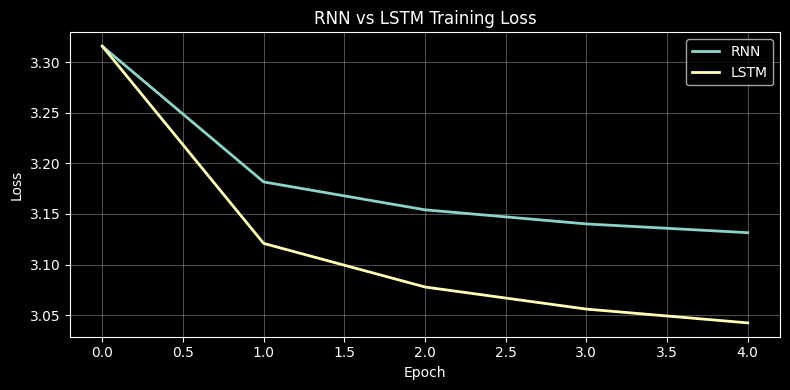

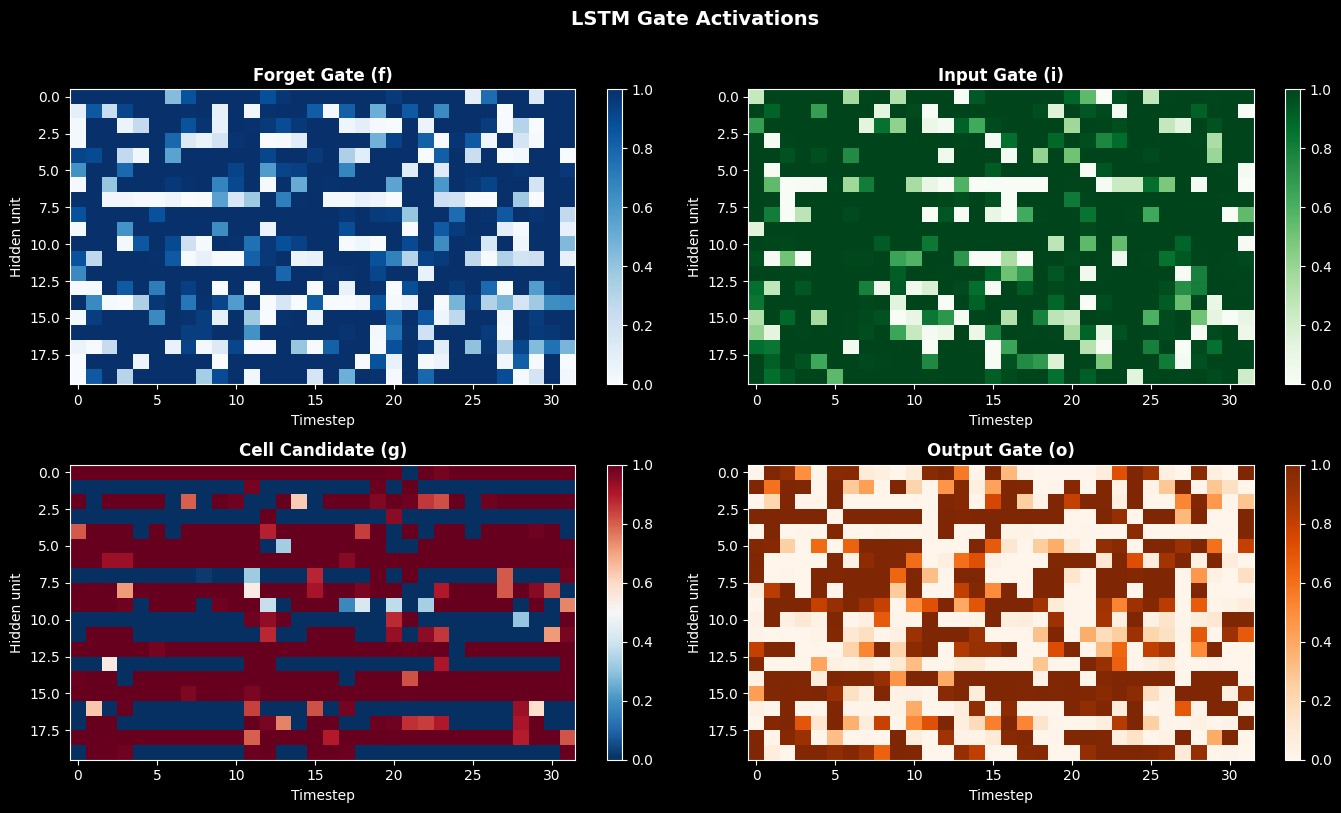

In [17]:
import matplotlib.pyplot as plt

# Side-by-side loss comparison
plt.figure(figsize=(8, 4))
plt.plot(rnn_losses,  label='RNN',  linewidth=2)
plt.plot(lstm_losses, label='LSTM', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN vs LSTM Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gate activation heatmap on one example
with torch.no_grad():
    sample = inputs[:1]
    emb = lstm_model.embedding(sample)
    h, c = torch.zeros(1, 128), torch.zeros(1, 128)
    gates_dict = {'forget': [], 'input': [], 'gate': [], 'output': []}
    for t in range(emb.shape[1]):
        raw = emb[:, t, :] @ lstm_model.W_x + h @ lstm_model.W_h + lstm_model.b
        hs = 128
        gates_dict['forget'].append(torch.sigmoid(raw[:, 0*hs:1*hs])[0].numpy())
        gates_dict['input'].append( torch.sigmoid(raw[:, 1*hs:2*hs])[0].numpy())
        gates_dict['gate'].append(  torch.tanh(   raw[:, 2*hs:3*hs])[0].numpy())
        gates_dict['output'].append(torch.sigmoid(raw[:, 3*hs:4*hs])[0].numpy())
        h, c = ch08_lstm.lstm_step(emb[:, t, :], h, c,
                                   lstm_model.W_x, lstm_model.W_h, lstm_model.b)
    gates_dict = {k: np.array(v) for k, v in gates_dict.items()}

viz.plot_gate_activations(gates_dict)


### Sample Output — LSTM

The LSTM has a cell state that can carry information across longer spans.
Compare the output quality to the RNN above — the LSTM should produce more coherent phrases.

In [ ]:
samples = {}
for prompt in ["the", "in the", "he was"]:
    samples[f'"{prompt}"'] = ch11_generation.generate(
        lstm_model, tokenizer, prompt, max_new_tokens=40, strategy='greedy'
    )
viz.plot_generation_samples(samples)

In [ ]:
torch.save(lstm_model.state_dict(), '../models/lstm_model.pt')
print("Saved: models/lstm_model.pt")

**Key Takeaway:**
> We can remember longer, but the sequential architecture and compressed memory are now the bottleneck.

---

# Chapter 9: Attention Mechanism

**Track:** Prediction  
**Question:** What if the model could look back at all previous positions and choose what's relevant right now?

---

## 9.1  Scaled Dot-Product Attention

- **Query / Key / Value** — Q asks "what do I need?", K answers "what do I have?", V carries content
- **Direct lookup** — any position can attend to any other position in one step (no bottleneck)
- **Scale by $\sqrt{d_k}$** — prevents softmax saturation when $d_k$ is large

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

| Symbol | Meaning |
|--------|---------|
| $Q$ | $(B, L, d_k)$ — queries |
| $K$ | $(B, L, d_k)$ — keys |
| $V$ | $(B, L, d_v)$ — values |
| $\sqrt{d_k}$ | Scaling factor |

## 9.1 Exercise

Implement scaled dot-product attention.

In [19]:
def your_scaled_dot_product_attention(Q, K, V, mask=None):
    """Scaled dot-product attention.

    Args:
        Q:    (batch, q_len, d_k)
        K:    (batch, k_len, d_k)
        V:    (batch, k_len, d_v)
        mask: (batch, q_len, k_len) bool — True positions are set to -inf

    Returns:
        output:  (batch, q_len, d_v)
        weights: (batch, q_len, k_len)
    """
    d_k = Q.shape[-1]

    # TODO: implement this
    scores = ...

    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))

    # TODO: implement this
    weights = ...

    # TODO: implement this
    output = ...

    return output, weights

# Shape check
Q_test = torch.randn(2, 5, 16)   # batch=2, 5 query positions, d_k=16
K_test = torch.randn(2, 5, 16)   # same for keys
V_test = torch.randn(2, 5, 32)   # d_v=32

try:
    out, w = your_scaled_dot_product_attention(Q_test, K_test, V_test)
    print(f"output shape:  {out.shape}   (expected: (2, 5, 32))")
    print(f"weights shape: {w.shape}    (expected: (2, 5, 5))")
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODOs above, then re-run")

[NOT IMPLEMENTED] — fill in the TODOs above, then re-run


## 9.1 Verify & Compare

In [20]:
ref_out, ref_w = ch09_attention.scaled_dot_product_attention(Q_test, K_test, V_test)

try:
    your_out, your_w = your_scaled_dot_product_attention(Q_test, K_test, V_test)
    your_out_np = your_out.detach().numpy()
    your_w_np   = your_w.detach().numpy()
except Exception:
    your_out_np = ...
    your_w_np   = ...

viz.compare(your_out_np, ref_out.detach().numpy())
viz.compare(your_w_np, ref_w.detach().numpy())
your_out = viz.resolve(your_out_np, ref_out.detach().numpy())
your_w   = viz.resolve(your_w_np, ref_w.detach().numpy())

[NOT IMPLEMENTED] Found ... placeholder
[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation
[SKIPPED] Using reference implementation


## 9.1 Visualize

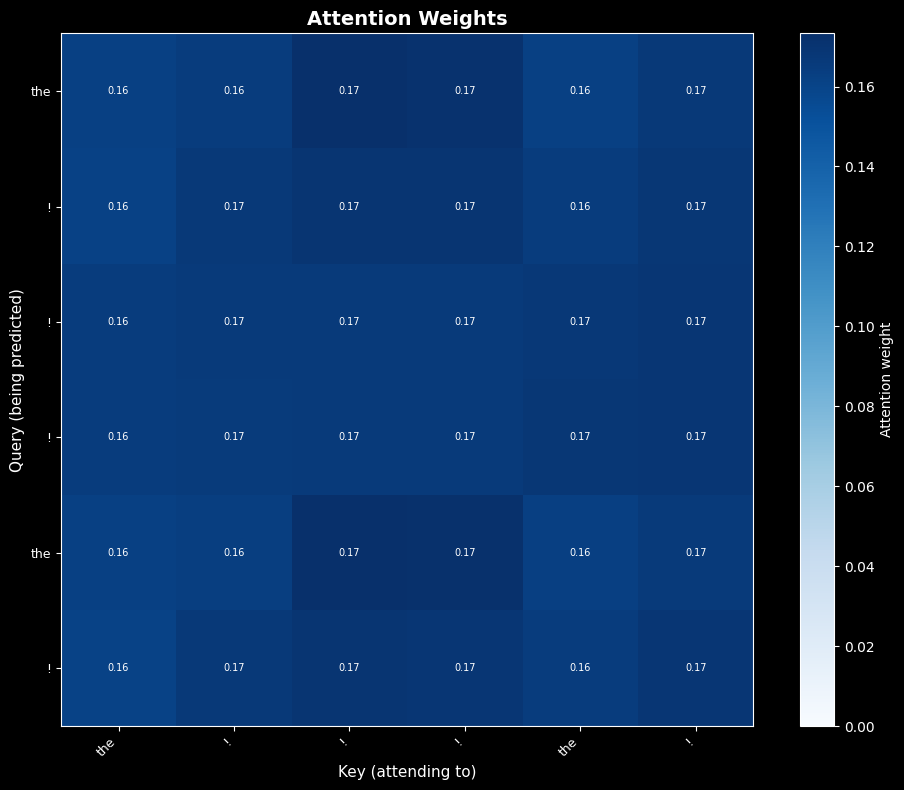

In [21]:
# Show attention weights for a short sample sequence
sample_ids = tokenizer.encode_ids("the cat sat on the mat")[:8]
sample_tensor = torch.tensor(sample_ids).unsqueeze(0)  # (1, seq)

attn_layer = ch09_attention.AttentionLayer(hidden_size=128, attention_dim=64)

# Use LSTM hidden states as input to attention
with torch.no_grad():
    emb = lstm_model.embedding(sample_tensor)
    h, c = torch.zeros(1, 128), torch.zeros(1, 128)
    h_list = []
    for t in range(emb.shape[1]):
        h, c = ch08_lstm.lstm_step(emb[:, t, :], h, c,
                                   lstm_model.W_x, lstm_model.W_h, lstm_model.b)
        h_list.append(h)
    h_seq = torch.stack(h_list, dim=1)   # (1, seq, 128)
    _, weights = attn_layer(h_seq)       # (1, seq, seq)

token_labels = [tokenizer.decode_ids([t]) for t in sample_ids]
viz.plot_attention_weights(weights[0].numpy(), token_labels)


## 9.2  RNN + Attention

- **LSTM encodes** — produces a hidden state $h_t$ at every position
- **Attention aggregates** — at each step, weights all hidden states by relevance
- **Context vector** — replaces single $h_T$ bottleneck with a dynamic mix of all positions
- **Still sequential** — LSTM must run step-by-step; removing it entirely → Transformer

## 9.2 Exercise

Fill in the forward pass of `RNNWithAttention`.

In [22]:
def your_attention_forward(h_seq, attention_layer):
    """Apply attention to a sequence of hidden states.

    Args:
        h_seq:           (batch, seq_len, hidden_size)
        attention_layer: AttentionLayer instance

    Returns:
        context: (batch, seq_len, hidden_size) — attended representation
        weights: (batch, seq_len, seq_len)
    """
    # TODO: implement this
    context, weights = ...
    return context, weights

print("Sketch defined — implement your_attention_forward above")


Sketch defined — implement your_attention_forward above


## 9.2 Verify & Compare

In [23]:
print("Training LSTM + Attention model...")
attn_model = ch09_attention.RNNWithAttention(VOCAB_SIZE, embed_dim=64, hidden_size=128)
attn_model, attn_losses = ch09_attention.train_attention(
    attn_model, inputs, targets,
    n_epochs=5, batch_size=64, lr=1e-3, verbose=True
)
print(f"\nLSTM final loss:         {lstm_losses[-1]:.4f}")
print(f"LSTM+Attention final loss: {attn_losses[-1]:.4f}")

Training LSTM + Attention model...
Epoch 1/5  loss: 0.2001
Epoch 2/5  loss: 0.1263
Epoch 3/5  loss: 0.1207
Epoch 4/5  loss: 0.1217
Epoch 5/5  loss: 0.1196

LSTM final loss:         3.0423
LSTM+Attention final loss: 0.1196


## 9.2 Visualize

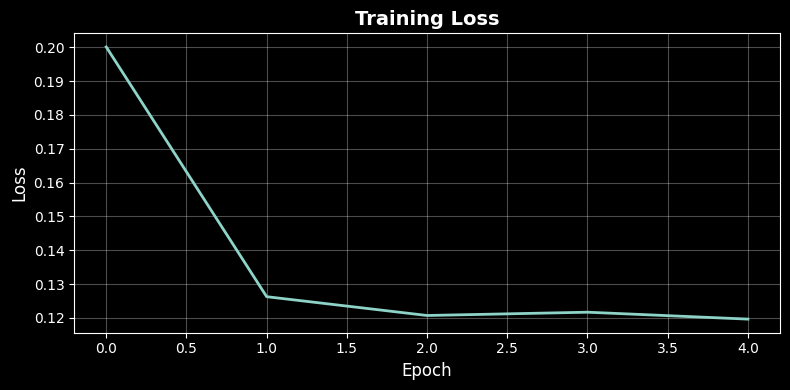

In [24]:
viz.plot_loss_curve(attn_losses, xlabel="Epoch")

### Sample Output — RNN with Attention

Attention lets the model look back at all previous tokens when deciding what comes next,
instead of relying only on the hidden state. Notice how the output compares to the plain LSTM.

In [ ]:
samples = {}
for prompt in ["the", "in the", "he was"]:
    samples[f'"{prompt}"'] = ch11_generation.generate(
        attn_model, tokenizer, prompt, max_new_tokens=40, strategy='greedy'
    )
viz.plot_generation_samples(samples)

In [ ]:
torch.save(attn_model.state_dict(), '../models/attn_model.pt')
print("Saved: models/attn_model.pt")

**Key Takeaway:**
> Attention lets the model look anywhere in the sequence, but the sequential backbone underneath is holding us back.

---

# Chapter 10: The Transformer

**Track:** Prediction + Representation  
**Question:** What if we throw away the RNN entirely and use *only* attention?

---

## 10.1  Causal Mask & Positional Encoding

- **No recurrence** → no implicit order; must inject position explicitly
- **Sinusoidal PE** — unique vector per position added to token embedding before any layer
- **Causal mask** — set future attention scores to $-\infty$; softmax → 0; no cheating

$$\text{PE}(\text{pos}, 2i) = \sin\!\left(\tfrac{\text{pos}}{10000^{2i/d}}\right) \quad
\text{mask}[i,j] = \begin{cases}-\infty & j>i\\ 0 & j\leq i\end{cases}$$

| | |
|-|-|
| PE adds position | token embedding + positional vector |
| mask blocks future | upper triangle = $-\infty$ before softmax |

## 10.1 Exercise

Implement the causal mask and positional encoding.

In [26]:
def your_make_causal_mask(seq_len, device=None):
    """Upper-triangular causal mask.

    Returns a BoolTensor of shape (1, seq_len, seq_len).
    True  = masked (future) — will become -inf in attention scores.
    False = allowed (past or current).
    """
    # TODO: implement this
    # Hint: torch.ones(..., dtype=torch.bool) then torch.triu(..., diagonal=1)
    mask = ...
    return mask.unsqueeze(0)   # add batch dimension


def your_positional_encoding(seq_len, d_model, device=None):
    """Sinusoidal positional encoding. Returns (1, seq_len, d_model)."""
    import math
    pe  = torch.zeros(seq_len, d_model, device=device)
    pos = torch.arange(seq_len, dtype=torch.float, device=device).unsqueeze(1)
    # TODO: implement this
    div = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float, device=device)
        * ...
    )
    # TODO: implement this
    pe[:, 0::2] = ...
    # TODO: implement this
    pe[:, 1::2] = ...
    return pe.unsqueeze(0)

# Tests
try:
    m = your_make_causal_mask(5)
    pe = your_positional_encoding(10, 16)
    print(f"Mask shape: {m.shape}")
    print(f"Mask (5x5):\n{m[0].int()}")
    print(f"PE shape: {pe.shape}")
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODOs above, then re-run")

[NOT IMPLEMENTED] — fill in the TODOs above, then re-run


## 10.1 Verify & Compare

In [27]:
ref_mask = ch10_transformer.make_causal_mask(5)
ref_pe   = ch10_transformer.positional_encoding(10, 16)

try:
    your_mask = your_make_causal_mask(5)
    your_mask_np = your_mask.numpy().astype(int)
except Exception:
    your_mask_np = ...

viz.compare(your_mask_np, ref_mask.numpy().astype(int))
your_mask = viz.resolve(your_mask_np, ref_mask.numpy().astype(int))

try:
    your_pe = your_positional_encoding(10, 16)
    your_pe_np = your_pe.numpy()
except Exception:
    your_pe_np = ...

viz.compare(your_pe_np, ref_pe.numpy())
your_pe = viz.resolve(your_pe_np, ref_pe.numpy())

[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation
[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation


## 10.1 Visualize

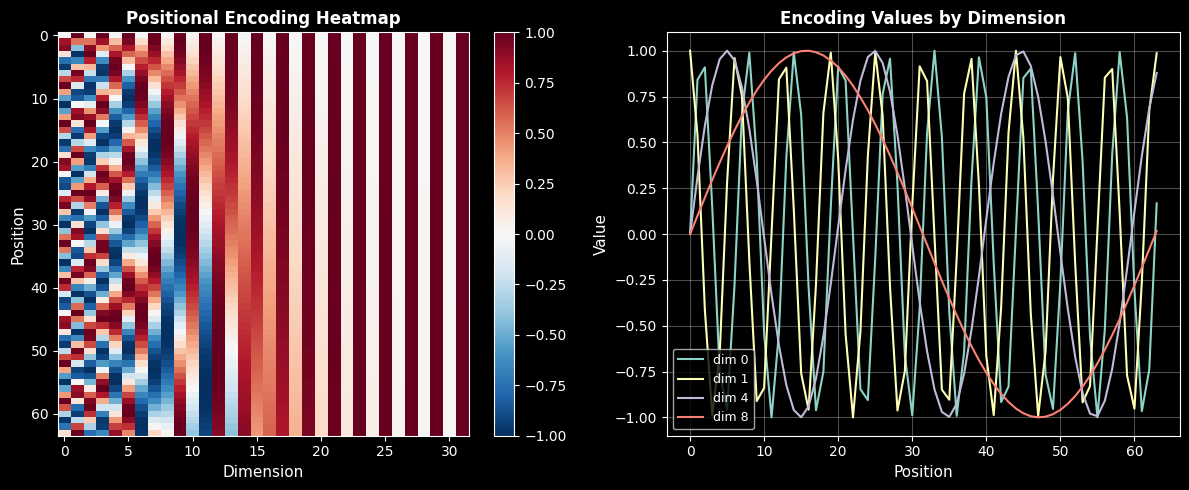

In [28]:
pe_display = ch10_transformer.positional_encoding(64, 32)
viz.plot_positional_encoding(pe_display)

## 10.2  Multi-Head Attention

- **$h$ parallel heads** — each sees a $d_\text{model}/h$ slice; same total compute
- **Different relationships** — head 1: subject-verb; head 2: coreference; head 3: local bigrams
- **Concatenate + project** — outputs merged back to $d_\text{model}$ via $W^O$

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1,\ldots,\text{head}_h)\,W^O$$

| Symbol | Meaning |
|--------|---------|
| $h$ | Number of heads |
| $d_\text{head} = d_\text{model}/h$ | Each head's dimension |
| $W^O$ | Output projection back to $d_\text{model}$ |

## 10.2 Exercise

Implement the multi-head attention forward pass.

In [29]:
class YourMultiHeadAttention(nn.Module):
    """Multi-head self-attention."""

    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        batch, seq_len, _ = x.shape

        # Project and split into heads: (batch, n_heads, seq, d_head)
        Q = self.W_q(x).view(batch, seq_len, self.n_heads, self.d_head).transpose(1, 2)
        # TODO: implement this
        K = ...
        # TODO: implement this
        V = ...

        # Reshape to (batch*n_heads, seq, d_head) for reuse of our attention primitive
        bh = batch * self.n_heads
        Q_ = Q.contiguous().view(bh, seq_len, self.d_head)
        K_ = K.contiguous().view(bh, seq_len, self.d_head)
        V_ = V.contiguous().view(bh, seq_len, self.d_head)

        if mask is not None:
            mask_ = mask.expand(batch, self.n_heads, seq_len, seq_len) \
                        .contiguous().view(bh, seq_len, seq_len)
        else:
            mask_ = None

        # TODO: implement this
        context, weights_flat = ...

        # Reassemble: (batch, seq, d_model) then project
        context = context.view(batch, self.n_heads, seq_len, self.d_head)
        context = context.transpose(1, 2).contiguous().view(batch, seq_len, self.d_model)
        output  = self.W_o(context)
        weights = weights_flat.view(batch, self.n_heads, seq_len, seq_len)
        return output, weights

# Test
d_model, n_heads, seq = 32, 4, 8
mha_test = YourMultiHeadAttention(d_model, n_heads)
x_test   = torch.randn(2, seq, d_model)

try:
    out_test, w_test = mha_test(x_test)
    print(f"Output shape:  {out_test.shape}   (expected: (2, {seq}, {d_model}))")
    print(f"Weights shape: {w_test.shape} (expected: (2, {n_heads}, {seq}, {seq}))")
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODOs above, then re-run")

[NOT IMPLEMENTED] — fill in the TODOs above, then re-run


## 10.2 Verify & Compare

In [30]:
ref_mha = ch10_transformer.MultiHeadAttention(d_model, n_heads)
ref_mha.load_state_dict(mha_test.state_dict())

ref_out, ref_w = ref_mha(x_test)

try:
    your_out, your_w = mha_test(x_test)
    your_out_np = your_out.detach().numpy()
except Exception:
    your_out_np = ...

viz.compare(your_out_np, ref_out.detach().numpy())
your_out = viz.resolve(your_out_np, ref_out.detach().numpy())

[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation


## 10.3  Transformer Block

- **Residual connection** — $x + \text{SubLayer}(x)$; gradient highway bypasses the layer
- **Layer norm** — normalizes activations per token; stabilizes deep stacks
- **Feed-forward** — two linear layers with GELU; each position processed independently
- **Stack $N$ blocks** — each refines the representation; deeper = more abstract

$$x \leftarrow \text{LN}(x + \text{MHA}(x)) \qquad x \leftarrow \text{LN}(x + \text{FFN}(x))$$

| Component | Purpose |
|-----------|---------|
| Residual $x + f(x)$ | Unblocked gradient flow |
| LayerNorm | Stable activation scale |
| FFN | Per-position nonlinearity |

## 10.3 Exercise

Implement the transformer block forward pass.

In [31]:
class YourTransformerBlock(nn.Module):
    """Single transformer decoder block."""

    def __init__(self, d_model, n_heads):
        super().__init__()
        self.attn  = ch10_transformer.MultiHeadAttention(d_model, n_heads)
        self.ff    = ch10_transformer.FeedForward(d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        """
        x: (batch, seq_len, d_model)
        Returns: x (same shape), weights (batch, n_heads, seq, seq)
        """
        attn_out, weights = self.attn(x, mask)
        # TODO: implement this
        x = ...

        # TODO: implement this
        x = ...

        return x, weights

# Test
block_test = YourTransformerBlock(d_model=32, n_heads=4)
x_b = torch.randn(2, 8, 32)

try:
    out_b, w_b = block_test(x_b)
    print(f"Block output shape: {out_b.shape}   (expected: (2, 8, 32))")
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODOs above, then re-run")

[NOT IMPLEMENTED] — fill in the TODOs above, then re-run


## 10.3 Verify & Compare

In [32]:
ref_block = ch10_transformer.TransformerBlock(d_model=32, n_heads=4)
ref_block.load_state_dict(block_test.state_dict())

ref_out_b, _ = ref_block(x_b)

try:
    your_out_b, _ = block_test(x_b)
    your_out_b_np = your_out_b.detach().numpy()
except Exception:
    your_out_b_np = ...

viz.compare(your_out_b_np, ref_out_b.detach().numpy())
your_out_b = viz.resolve(your_out_b_np, ref_out_b.detach().numpy())

[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation


## 10.4  Full Transformer Language Model

- **Embed + PE** — token ID → dense vector + positional encoding
- **$N$ blocks** — each block refines all positions in parallel (no sequential constraint)
- **Output head** — final hidden state → linear → logits over vocabulary
- **Contextual embeddings** — "bank" in "river bank" ≠ "bank" in "bank account"; emerges automatically

## 10.4 Exercise

Identify the key steps in the transformer forward pass.

In [33]:
# The full model is in ch10_transformer.TransformerLanguageModel.
# Trace through its forward method to answer these questions:

t_model = ch10_transformer.TransformerLanguageModel(
    vocab_size=VOCAB_SIZE, d_model=64, n_heads=4, n_layers=2
)

x_sample = inputs[:4]   # 4 sequences
with torch.no_grad():
    logits, all_weights = t_model(x_sample)

# Fill in the expected shapes:
print(f"Input shape:        {x_sample.shape}")
print(f"Logits shape:       {logits.shape}")
print(f"Number of layers:   {len(all_weights)}")
print(f"Weights[0] shape:   {all_weights[0].shape}")
print()
print(f"Expected logits shape: (4, {SEQ_LEN}, {VOCAB_SIZE})")

Input shape:        torch.Size([4, 32])
Logits shape:       torch.Size([4, 32, 2000])
Number of layers:   2
Weights[0] shape:   torch.Size([4, 4, 32, 32])

Expected logits shape: (4, 32, 2000)


## 10.4 Verify & Compare

In [34]:
print("Training Transformer language model...")
transformer = ch10_transformer.TransformerLanguageModel(
    vocab_size=VOCAB_SIZE, d_model=64, n_heads=4, n_layers=2
)
transformer, tf_losses = ch10_transformer.train_transformer(
    transformer, inputs, targets,
    n_epochs=10, batch_size=64, lr=3e-4, verbose=True
)
print(f"\nRNN final loss:         {rnn_losses[-1]:.4f}")
print(f"LSTM final loss:        {lstm_losses[-1]:.4f}")
print(f"Transformer final loss: {tf_losses[-1]:.4f}")

Training Transformer language model...
Epoch 1/10  loss: 3.7255
Epoch 2/10  loss: 3.3637
Epoch 3/10  loss: 3.2844
Epoch 4/10  loss: 3.2401
Epoch 5/10  loss: 3.2110
Epoch 6/10  loss: 3.1898
Epoch 7/10  loss: 3.1737
Epoch 8/10  loss: 3.1609
Epoch 9/10  loss: 3.1504
Epoch 10/10  loss: 3.1418

RNN final loss:         3.1315
LSTM final loss:        3.0423
Transformer final loss: 3.1418


## 10.4 Visualize

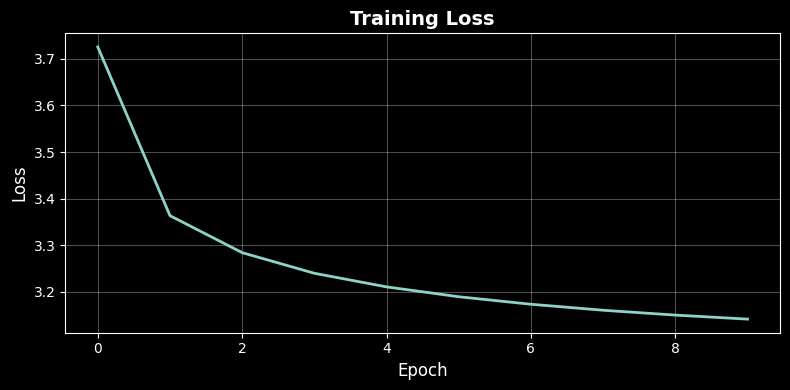

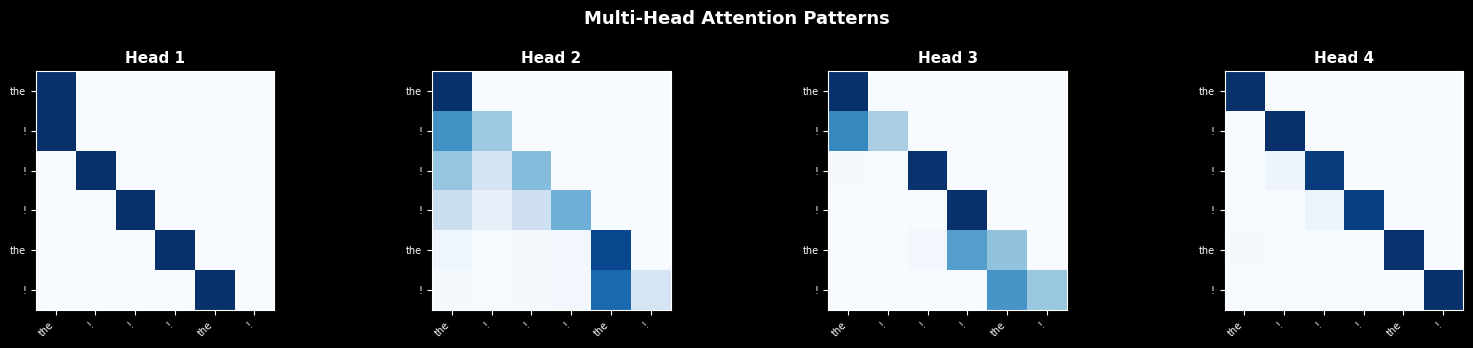

In [35]:
viz.plot_loss_curve(tf_losses, xlabel="Epoch")

# Multi-head attention patterns on a short sequence
sample_ids = tokenizer.encode_ids("the cat sat on the mat")[:8]
s_tensor = torch.tensor(sample_ids).unsqueeze(0)

with torch.no_grad():
    _, all_w = transformer(s_tensor)

token_labels = [tokenizer.decode_ids([t]) for t in sample_ids]
# Show first layer's weights, removing batch dim
viz.plot_multi_head_attention(all_w[0][0].numpy(), token_labels)

### Sample Output — Transformer

The Transformer processes all positions in parallel and uses multi-head self-attention throughout.
This is the architecture behind GPT. Chapter 11 will give you full control over how it generates.

In [ ]:
samples = {}
for label, kwargs in [
    ('greedy',        dict(strategy='greedy')),
    ('temp=0.8',      dict(strategy='temperature', temperature=0.8)),
    ('top_k=40',      dict(strategy='top_k', k=40, temperature=0.9)),
    ('nucleus p=0.9', dict(strategy='nucleus', p=0.9, temperature=0.9)),
]:
    samples[label] = ch11_generation.generate(
        transformer, tokenizer, "the history of", max_new_tokens=40, **kwargs
    )
viz.plot_generation_samples(samples)

In [ ]:
torch.save(transformer.state_dict(), '../models/transformer.pt')
with open('../models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Saved: models/transformer.pt")
print("Saved: models/tokenizer.pkl")

**Key Takeaway:**
> The transformer processes all tokens in parallel, enables arbitrary-depth context, and produces contextual embeddings as a side effect. Both tracks converge here.

---

# Chapter 11: Autoregressive Generation

**Track:** Prediction (at inference time)  
**Question:** We have a trained model. How do we actually generate text?

---

## 11.1  The Autoregressive Loop

- **One token at a time** — forward pass on current sequence → distribution → sample → append → repeat
- **Prompt is just the start** — the model conditions on everything generated so far
- **Greedy** — always pick $\text{argmax}$; fast, deterministic, often repetitive

$$\hat{t}_{t+1} = \arg\max_v\; p(v \mid t_1, \ldots, t_t)$$

| Strategy | Rule |
|----------|------|
| Greedy | argmax — always top token |
| Sample | draw from full softmax |

## 11.1 Exercise

Implement greedy decoding.

In [37]:
def your_greedy_decode(model, prompt_ids, max_new_tokens=30):
    """Generate tokens greedily — always pick the highest-probability next token.

    Args:
        model:          TransformerLanguageModel
        prompt_ids:     LongTensor (seq_len,)
        max_new_tokens: How many tokens to generate

    Returns:
        LongTensor (seq_len + max_new_tokens,)
    """
    model.eval()
    ids = prompt_ids.clone().unsqueeze(0)   # (1, seq)
    max_ctx = model.max_seq_len

    with torch.no_grad():
        for _ in range(max_new_tokens):
            ctx = ids[:, -max_ctx:]
            # TODO: implement this
            logits, _ = ...
            # TODO: implement this
            next_logits = ...
            # TODO: implement this
            next_id = ...
            ids = torch.cat([ids, next_id.unsqueeze(0).unsqueeze(0)], dim=1)

    return ids[0]

# Quick check
prompt_tokens = tokenizer.encode_ids("the")
prompt_tensor = torch.tensor(prompt_tokens, dtype=torch.long)

try:
    generated = your_greedy_decode(transformer, prompt_tensor, max_new_tokens=10)
    print(f"Generated {len(generated) - len(prompt_tokens)} new tokens")
    print(tokenizer.decode_ids(generated.tolist()))
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODOs above, then re-run")

[NOT IMPLEMENTED] — fill in the TODOs above, then re-run


## 11.1 Verify & Compare

In [38]:
ref_generated = ch11_generation.greedy_decode(transformer, prompt_tensor, max_new_tokens=10)

try:
    your_generated = your_greedy_decode(transformer, prompt_tensor, max_new_tokens=10)
    your_generated_np = your_generated.numpy()
except Exception:
    your_generated_np = ...

viz.compare(your_generated_np, ref_generated.numpy())
your_generated = viz.resolve(your_generated_np, ref_generated.numpy())

print("\nGreedy output:", tokenizer.decode_ids(ref_generated.tolist()))

[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation

Greedy output: the !!!!!!!!!!


## 11.2  Temperature & Top-k Sampling

- **Temperature $T$** — divide logits by $T$ before softmax; $T<1$ sharpens, $T>1$ flattens
- **Top-k** — zero out all but the $k$ highest logits; eliminates low-prob "disasters"
- **Combine** — top-k first, then temperature, then sample

$$p_i^{(T)} = \frac{\exp(z_i/T)}{\sum_j \exp(z_j/T)}$$

| $T$ | Effect |
|-----|--------|
| $<1$ | More confident, less diverse |
| $=1$ | Unchanged softmax |
| $>1$ | More random, more creative |

## 11.2 Exercise

Implement top-k sampling.

In [39]:
def your_top_k_sample(logits, k, temperature=1.0):
    """Sample from the top-k most probable tokens.

    Args:
        logits:      (vocab_size,)
        k:           Number of tokens to keep
        temperature: Scale factor before softmax

    Returns:
        token_id: int
    """
    k = min(k, logits.shape[-1])
    # TODO: implement this
    top_k_values, _ = ...
    threshold = ...

    # TODO: implement this
    filtered = logits.clone()
    filtered[filtered < threshold] = float('-inf')

    # TODO: implement this
    scaled = filtered / temperature
    probs  = F.softmax(scaled, dim=-1)
    return ...

# Quick check
test_logits = torch.randn(VOCAB_SIZE)
try:
    token_id = your_top_k_sample(test_logits, k=10)
    print(f"Sampled token id: {token_id}  (valid: {0 <= token_id < VOCAB_SIZE})")
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODOs above, then re-run")

[NOT IMPLEMENTED] — fill in the TODOs above, then re-run


## 11.2 Verify & Compare

In [40]:
# Verify statistical behavior: top-k=1 should always return argmax
ref_greedy = test_logits.argmax().item()

try:
    deterministic_result = your_top_k_sample(test_logits, k=1, temperature=0.001)
except Exception:
    deterministic_result = ...

reference_result = ref_greedy
viz.compare(deterministic_result, reference_result)
deterministic_result = viz.resolve(deterministic_result, reference_result)

[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation


## 11.3  Nucleus (Top-p) Sampling

- **Problem with top-k** — fixed $k$ is too many when model is confident, too few when uncertain
- **Nucleus adapts** — sort by prob, keep the smallest prefix summing to $\geq p$
- **$p=0.9$** → sometimes 3 tokens suffice; sometimes 200 tokens needed

$$\text{nucleus}(p) = \text{smallest } S \text{ such that } \sum_{i \in S} p_i \geq p$$

| $p$ | Effect |
|-----|--------|
| low (0.5) | Conservative — high-confidence tokens only |
| high (0.95) | Liberal — wide creative range |

## 11.3 Exercise

Implement nucleus sampling and run the final generation comparison.

In [41]:
def your_nucleus_sample(logits, p, temperature=1.0):
    """Nucleus (top-p) sampling.

    Args:
        logits:      (vocab_size,)
        p:           Cumulative probability threshold (0 < p <= 1)
        temperature: Scaling factor

    Returns:
        token_id: int
    """
    scaled = logits / temperature
    probs  = F.softmax(scaled, dim=-1)

    # TODO: implement this
    sorted_probs, sorted_indices = ...

    # TODO: implement this
    cumulative = ...

    # TODO: implement this
    # Build remove mask: True for tokens where cumulative - prob > p
    # (shift by 1 so we keep at least the top token)
    remove_mask = ...

    sorted_probs[remove_mask] = 0.0
    sorted_probs = sorted_probs / sorted_probs.sum()   # renormalize
    sampled_idx  = torch.multinomial(sorted_probs, num_samples=1).item()
    return sorted_indices[sampled_idx].item()

try:
    nucleus_id = your_nucleus_sample(test_logits, p=0.9)
    print(f"Nucleus sample token id: {nucleus_id}")
except Exception:
    print("[NOT IMPLEMENTED] — fill in the TODOs above, then re-run")

[NOT IMPLEMENTED] — fill in the TODOs above, then re-run


## 11.3 Verify & Compare

In [42]:
# Compare generated text across strategies
prompt_text = "the history of"

samples = {}
for strategy, kwargs in [
    ('greedy',      dict(strategy='greedy')),
    ('temp=0.7',    dict(strategy='temperature', temperature=0.7)),
    ('top_k=40',    dict(strategy='top_k', k=40, temperature=0.9)),
    ('nucleus p=0.9', dict(strategy='nucleus', p=0.9, temperature=0.9)),
]:
    samples[strategy] = ch11_generation.generate(
        transformer, tokenizer, prompt_text, max_new_tokens=30, **kwargs
    )

for strategy, text in samples.items():
    print(f"[{strategy}]")
    print(f"  {text}")
    print()

[greedy]
  the !of the !!!!!!!!!!!!!!!!!!!!!!!!!!!!!

[temp=0.7]
  the !of the church , !the !!!!!!, !!!!!. the !!was !!!from the !!park

[top_k=40]
  the !of < unk > < unk > . !!!!!!is a !!, < unk > ( !or < unk > , < unk

[nucleus p=0.9]
  the !of < unk > < unk > !< unk > for its !from the !. the character of !roo!!the !of !!



## 11.3 Visualize

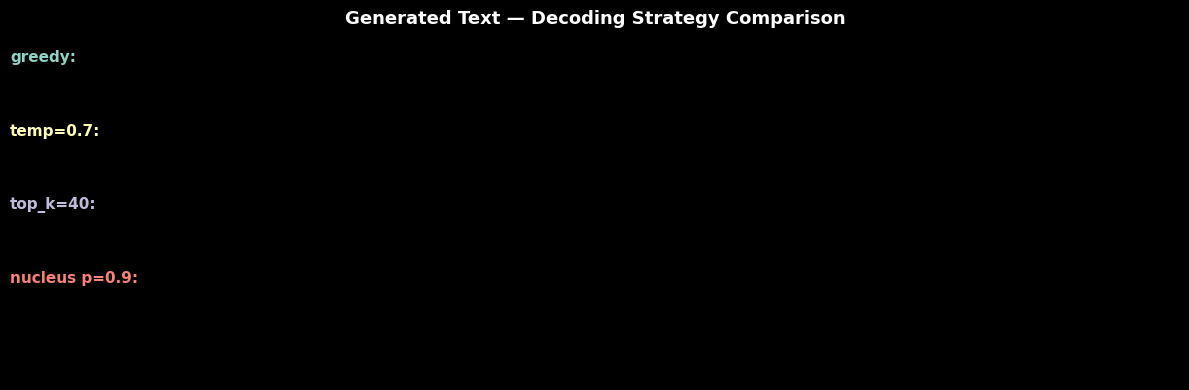

In [43]:
viz.plot_generation_samples(samples)

**Key Takeaway:**
> Generation is a loop: predict one token, append, repeat. Temperature, top-k, and top-p control the trade-off between coherence and creativity.

---

# Part II Summary

## The Complete Arc

| Chapter | Concept | Problem Solved |
|---------|---------|----------------|
| 7 | RNN | Sequential processing — order matters now |
| 8 | LSTM | Gated memory — long-range dependencies |
| 9 | Attention | Direct access to any past position |
| 10 | Transformer | Parallel + deep + contextual embeddings |
| 11 | Generation | Prompt → text via autoregressive sampling |

## The Two-Track Convergence

- **Representation track:** One-hot → Word2Vec → BPE → **Contextual embeddings (Transformer)**
- **Prediction track:** Linear regression → Logistic → MLP → RNN → LSTM → Attention → **Transformer** → Generation

Both tracks converge at the Transformer. The prediction architecture solves the representation problem as a side effect: contextual embeddings emerge from self-attention without any separate representation learning step.

## What You Now Have

Every conceptual and practical piece needed to implement a working GPT-style language model — from tokenization to generation.


---

## Loading Saved Models (for lecture / demo use)

All four trained models and the tokenizer are saved in `models/`. Use the snippet below to reload any of them without re-running the full notebook.

In [ ]:
import pickle, torch
from llmkit.solutions import ch07_rnn, ch08_lstm, ch09_attention, ch10_transformer, ch11_generation

# Load tokenizer
with open('../models/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
VOCAB_SIZE = len(tokenizer.vocab)

# Load models
rnn_model = ch07_rnn.RNNLanguageModel(VOCAB_SIZE, embed_dim=64, hidden_size=128)
rnn_model.load_state_dict(torch.load('../models/rnn_model.pt', weights_only=True))

lstm_model = ch08_lstm.LSTMLanguageModel(VOCAB_SIZE, embed_dim=64, hidden_size=128)
lstm_model.load_state_dict(torch.load('../models/lstm_model.pt', weights_only=True))

attn_model = ch09_attention.RNNWithAttention(VOCAB_SIZE, embed_dim=64, hidden_size=128)
attn_model.load_state_dict(torch.load('../models/attn_model.pt', weights_only=True))

transformer = ch10_transformer.TransformerLanguageModel(
    vocab_size=VOCAB_SIZE, d_model=64, n_heads=4, n_layers=2
)
transformer.load_state_dict(torch.load('../models/transformer.pt', weights_only=True))

print("All models loaded.")

# Quick demo
for name, model in [('RNN', rnn_model), ('LSTM', lstm_model),
                     ('Attention', attn_model), ('Transformer', transformer)]:
    out = ch11_generation.generate(model, tokenizer, "the", max_new_tokens=30, strategy='top_k', k=40)
    print(f"{name:12s}: {out}")